<h1>Metro Madrid: Análisis exploratorio de datos (EDA)</h1>

<p><b>Autor:</b> Victor San Miguel Monerris</p>
<b>Datos:</b> Dataset de Metro de Madrid: <a href="https://www.metromadrid.es/es/transparencia/proyectos-y-datos#panel1">Metro de Madrid

<h2>Campos y variables del dataset:</h2>

* **CodigoEstacion:** Código de la estación.
* **NombreEstacion:** Nombre de la estación.
* **Utilizaciones2014:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2015:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2016:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2017:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2018:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2019:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2020:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2021:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2022:** Utilizaciones de la estación en el año indicado.
* **Utilizaciones2023:** Utilizaciones de la estación en el año indicado.

<h2>Limpieza y preparación de los datos</h2>

Carga de las librerías necesarias:

In [1]:
#Importación de las librerías a utilizar:
%matplotlib inline
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean, mode, median
import numpy as np

Carga de los datos, visualización de los mismos y comprobación de datos duplicados:

In [2]:
#Carga del fichero csv con los datos:
datos = pd.read_csv("C:/Users/pc_vi/OneDrive/Escritorio/TFG/data/PA016_Utilizaciones_por_estaciones.csv", sep=";", encoding='latin-1')
#Formato/tipo de datos del dataset:
print(datos.dtypes)

CodigoEstacion        int64
NombreEstacion       object
Utilizaciones2014    object
Utilizaciones2015    object
Utilizaciones2016    object
Utilizaciones2017    object
Utilizaciones2018    object
Utilizaciones2019    object
Utilizaciones2020    object
Utilizaciones2021    object
Utilizaciones2022    object
Utilizaciones2023    object
dtype: object


In [3]:
datos.head()

,CodigoEstacion,NombreEstacion,Utilizaciones2014,Utilizaciones2015,Utilizaciones2016,Utilizaciones2017,Utilizaciones2018,Utilizaciones2019,Utilizaciones2020,Utilizaciones2021,Utilizaciones2022,Utilizaciones2023
0,101,Plaza de Castilla,33.030.381,32.948.701,32.711.005,36.577.999,37.361.848,38.173.875,20.578.972,25.135.236,31.752.903,38.633.202
1,102,Valdeacederas,4.696.101,4.835.598,3.836.045,5.117.306,5.038.540,5.540.194,3.089.304,3.877.235,4.697.721,5.392.944
2,103,Tetuán,5.845.624,5.935.352,4.824.501,6.276.574,6.895.295,7.148.217,3.877.174,5.039.721,6.276.060,7.120.713
3,104,Estrecho,7.308.023,7.205.990,5.953.996,5.530.388,9.203.377,9.974.619,5.545.797,7.040.773,8.686.545,9.914.380
4,105,Alvarado,5.093.951,5.193.500,3.971.317,5.233.752,3.463.184,4.017.667,2.306.788,3.173.254,3.790.083,4.232.367


Los datos no son de tipo objecto:

- El código de la estación no es decimal, es un número entero (hay que cambiarlo).
- Las utilizaciones del Metro de Madrid en todos los años son un número entero (hay que cambiarlo).

Las cifras tienen punto de millares, por eso el tipo de dato lo puede interpretar como object, por lo que se suprime. El nombre de la estación debe ser un String, no un Object.

In [4]:
#Quitar punto de los miles:
def quitar_punto_miles(valor):
    if isinstance(valor, str):
        return valor.replace('.', '')
    return valor
datos = datos.applymap(quitar_punto_miles)
#Codigo de la estacion de float a int:
datos['CodigoEstacion'] = datos['CodigoEstacion'].fillna(0).astype(int) #fillna sustituye NaN por un 0
#Utilizacion de las estaciones de object a int:
datos['Utilizaciones2014'] = datos['Utilizaciones2014'].fillna(0).astype(int)
datos['Utilizaciones2015'] = datos['Utilizaciones2015'].fillna(0).astype(int)
datos['Utilizaciones2016'] = datos['Utilizaciones2016'].fillna(0).astype(int)
datos['Utilizaciones2017'] = datos['Utilizaciones2017'].fillna(0).astype(int)
datos['Utilizaciones2018'] = datos['Utilizaciones2018'].fillna(0).astype(int)
datos['Utilizaciones2019'] = datos['Utilizaciones2019'].fillna(0).astype(int)
datos['Utilizaciones2020'] = datos['Utilizaciones2020'].fillna(0).astype(int)
datos['Utilizaciones2021'] = datos['Utilizaciones2021'].fillna(0).astype(int)
datos['Utilizaciones2022'] = datos['Utilizaciones2022'].fillna(0).astype(int) 
datos['Utilizaciones2023'] = datos['Utilizaciones2023'].fillna(0).astype(int) 
datos.head()

C:\Users\pc_vi\AppData\Local\Temp\ipykernel_88188\918994571.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  datos = datos.applymap(quitar_punto_miles)


,CodigoEstacion,NombreEstacion,Utilizaciones2014,Utilizaciones2015,Utilizaciones2016,Utilizaciones2017,Utilizaciones2018,Utilizaciones2019,Utilizaciones2020,Utilizaciones2021,Utilizaciones2022,Utilizaciones2023
0,101,Plaza de Castilla,33030381,32948701,32711005,36577999,37361848,38173875,20578972,25135236,31752903,38633202
1,102,Valdeacederas,4696101,4835598,3836045,5117306,5038540,5540194,3089304,3877235,4697721,5392944
2,103,Tetuán,5845624,5935352,4824501,6276574,6895295,7148217,3877174,5039721,6276060,7120713
3,104,Estrecho,7308023,7205990,5953996,5530388,9203377,9974619,5545797,7040773,8686545,9914380
4,105,Alvarado,5093951,5193500,3971317,5233752,3463184,4017667,2306788,3173254,3790083,4232367


In [5]:
datos.dtypes

CodigoEstacion        int32
NombreEstacion       object
Utilizaciones2014     int32
Utilizaciones2015     int32
Utilizaciones2016     int32
Utilizaciones2017     int32
Utilizaciones2018     int32
Utilizaciones2019     int32
Utilizaciones2020     int32
Utilizaciones2021     int32
Utilizaciones2022     int32
Utilizaciones2023     int32
dtype: object

In [6]:
#Devuelve el tamaño del csv leído:
print(datos.shape)
#Comprueba si hay datos duplicados:
print("--------------")
print(datos.duplicated(keep=False).sum(),"datos duplicados")
duplicados = datos[datos.duplicated(keep=False)]
print(duplicados)
#Previsualiza 5 filas aleatorias para tener una idea del csv:
print("--------------")
datos.head()

(237, 12)
--------------
0 datos duplicados
Empty DataFrame
Columns: [CodigoEstacion, NombreEstacion, Utilizaciones2014, Utilizaciones2015, Utilizaciones2016, Utilizaciones2017, Utilizaciones2018, Utilizaciones2019, Utilizaciones2020, Utilizaciones2021, Utilizaciones2022, Utilizaciones2023]
Index: []
--------------


,CodigoEstacion,NombreEstacion,Utilizaciones2014,Utilizaciones2015,Utilizaciones2016,Utilizaciones2017,Utilizaciones2018,Utilizaciones2019,Utilizaciones2020,Utilizaciones2021,Utilizaciones2022,Utilizaciones2023
0,101,Plaza de Castilla,33030381,32948701,32711005,36577999,37361848,38173875,20578972,25135236,31752903,38633202
1,102,Valdeacederas,4696101,4835598,3836045,5117306,5038540,5540194,3089304,3877235,4697721,5392944
2,103,Tetuán,5845624,5935352,4824501,6276574,6895295,7148217,3877174,5039721,6276060,7120713
3,104,Estrecho,7308023,7205990,5953996,5530388,9203377,9974619,5545797,7040773,8686545,9914380
4,105,Alvarado,5093951,5193500,3971317,5233752,3463184,4017667,2306788,3173254,3790083,4232367


239 filas y 11 columnas, con 2 datos duplicados, las filas 237 y 238, ambas filas vacías, por lo que se eliminan.

In [7]:
# Cambiar los valores de 0 a 11.000.000 (para evitar problemas futuros)
datos.replace(0, 11000000, inplace=True)
datos.to_csv('Metro_CleanedData.csv', index=False)

<h2>Análisis Exploratorio de los Datos</h2>

In [8]:
datos.describe()

,CodigoEstacion,Utilizaciones2014,Utilizaciones2015,Utilizaciones2016,Utilizaciones2017,Utilizaciones2018,Utilizaciones2019,Utilizaciones2020,Utilizaciones2021,Utilizaciones2022,Utilizaciones2023
count,237.000000,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02
mean,629.345992,5.955827e+06,5.975241e+06,6.042906e+06,6.611230e+06,6.792230e+06,7.205284e+06,3.743986e+06,4.741547e+06,6.096508e+06,7.151259e+06
std,359.956269,7.601382e+06,7.618493e+06,7.754977e+06,8.488847e+06,8.741433e+06,9.419238e+06,4.842226e+06,6.080749e+06,7.678046e+06,8.873905e+06
min,101.000000,3.195320e+05,3.645020e+05,2.639800e+04,4.053340e+05,3.519710e+05,1.826530e+05,1.429010e+05,2.272280e+05,2.280690e+05,5.834770e+05
25%,310.000000,2.118290e+06,2.217782e+06,2.267292e+06,2.459123e+06,2.488684e+06,2.624806e+06,1.343771e+06,1.775639e+06,2.317488e+06,2.703299e+06
50%,609.000000,3.418120e+06,3.479807e+06,3.504763e+06,3.690737e+06,3.846570e+06,4.144771e+06,2.185348e+06,2.785882e+06,3.512622e+06,4.085878e+06
75%,920.000000,5.845624e+06,5.879855e+06,5.953996e+06,6.321562e+06,7.158034e+06,7.284930e+06,3.877174e+06,4.784869e+06,6.003329e+06,7.124266e+06
max,1230.000000,5.567303e+07,5.642766e+07,5.248274e+07,6.159848e+07,7.095362e+07,7.713581e+07,3.914985e+07,4.956708e+07,6.090839e+07,6.621882e+07


En todas las columnas hay 238 filas (count).

- La media de utilizaciones de Metro en 2014 es de 5.863.000
- La media de utilizaciones de Metro en 2015 es de 5.928.828 (aumento frente a 2014)
- La media de utilizaciones de Metro en 2016 es de 5.996.492 (aumento frente a 2015)
- La media de utilizaciones de Metro en 2017 es de 6.564.816 (aumento frente a 2016)
- La media de utilizaciones de Metro en 2018 es de 6.745.816 (aumento frente a 2017)
- La media de utilizaciones de Metro en 2019 es de 7.158.871 (aumento frente a 2018)
- La media de utilizaciones de Metro en 2020 es de 3.697.573 (disminución enorme)
- La media de utilizaciones de Metro en 2021 es de 4.741.547 (aumento frente a 2020)
- La media de utilizaciones de Metro en 2022 es de 6.096.508 (aumento frente a 2021)
- La media de utilizaciones de Metro en 2023 es de 7.151.259 (aumento frente a 2022)

Representación de la media de la utilización del Metro de Madrid:

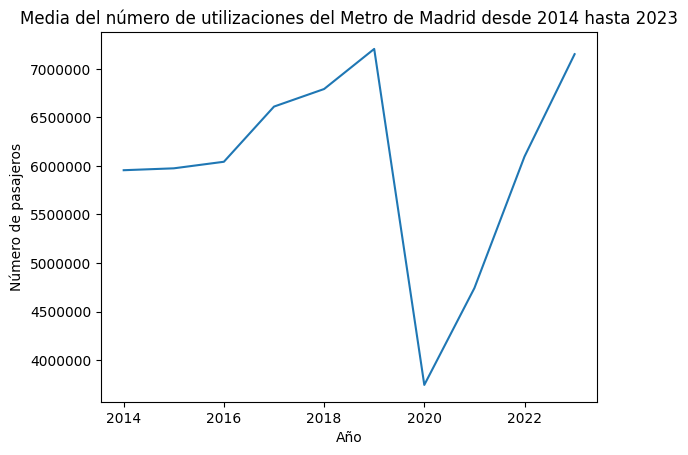

In [9]:
media2014 = mean(datos['Utilizaciones2014'])
media2015 = mean(datos['Utilizaciones2015'])
media2016 = mean(datos['Utilizaciones2016'])
media2017 = mean(datos['Utilizaciones2017'])
media2018 = mean(datos['Utilizaciones2018'])
media2019 = mean(datos['Utilizaciones2019'])
media2020 = mean(datos['Utilizaciones2020'])
media2021 = mean(datos['Utilizaciones2021'])
media2022 = mean(datos['Utilizaciones2022'])
media2023 = mean(datos['Utilizaciones2023'])
medias = [media2014,media2015,media2016,media2017,media2018,media2019,media2020,media2021,media2022,media2023]
anios = [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]
plt.plot(anios,medias)
plt.title('Media del número de utilizaciones del Metro de Madrid desde 2014 hasta 2023')
plt.ylabel('Número de pasajeros')
plt.xlabel('Año')
plt.ticklabel_format(useOffset=False, style='plain')

C:\Users\pc_vi\miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\pc_vi\miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\pc_vi\miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\pc_vi\miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

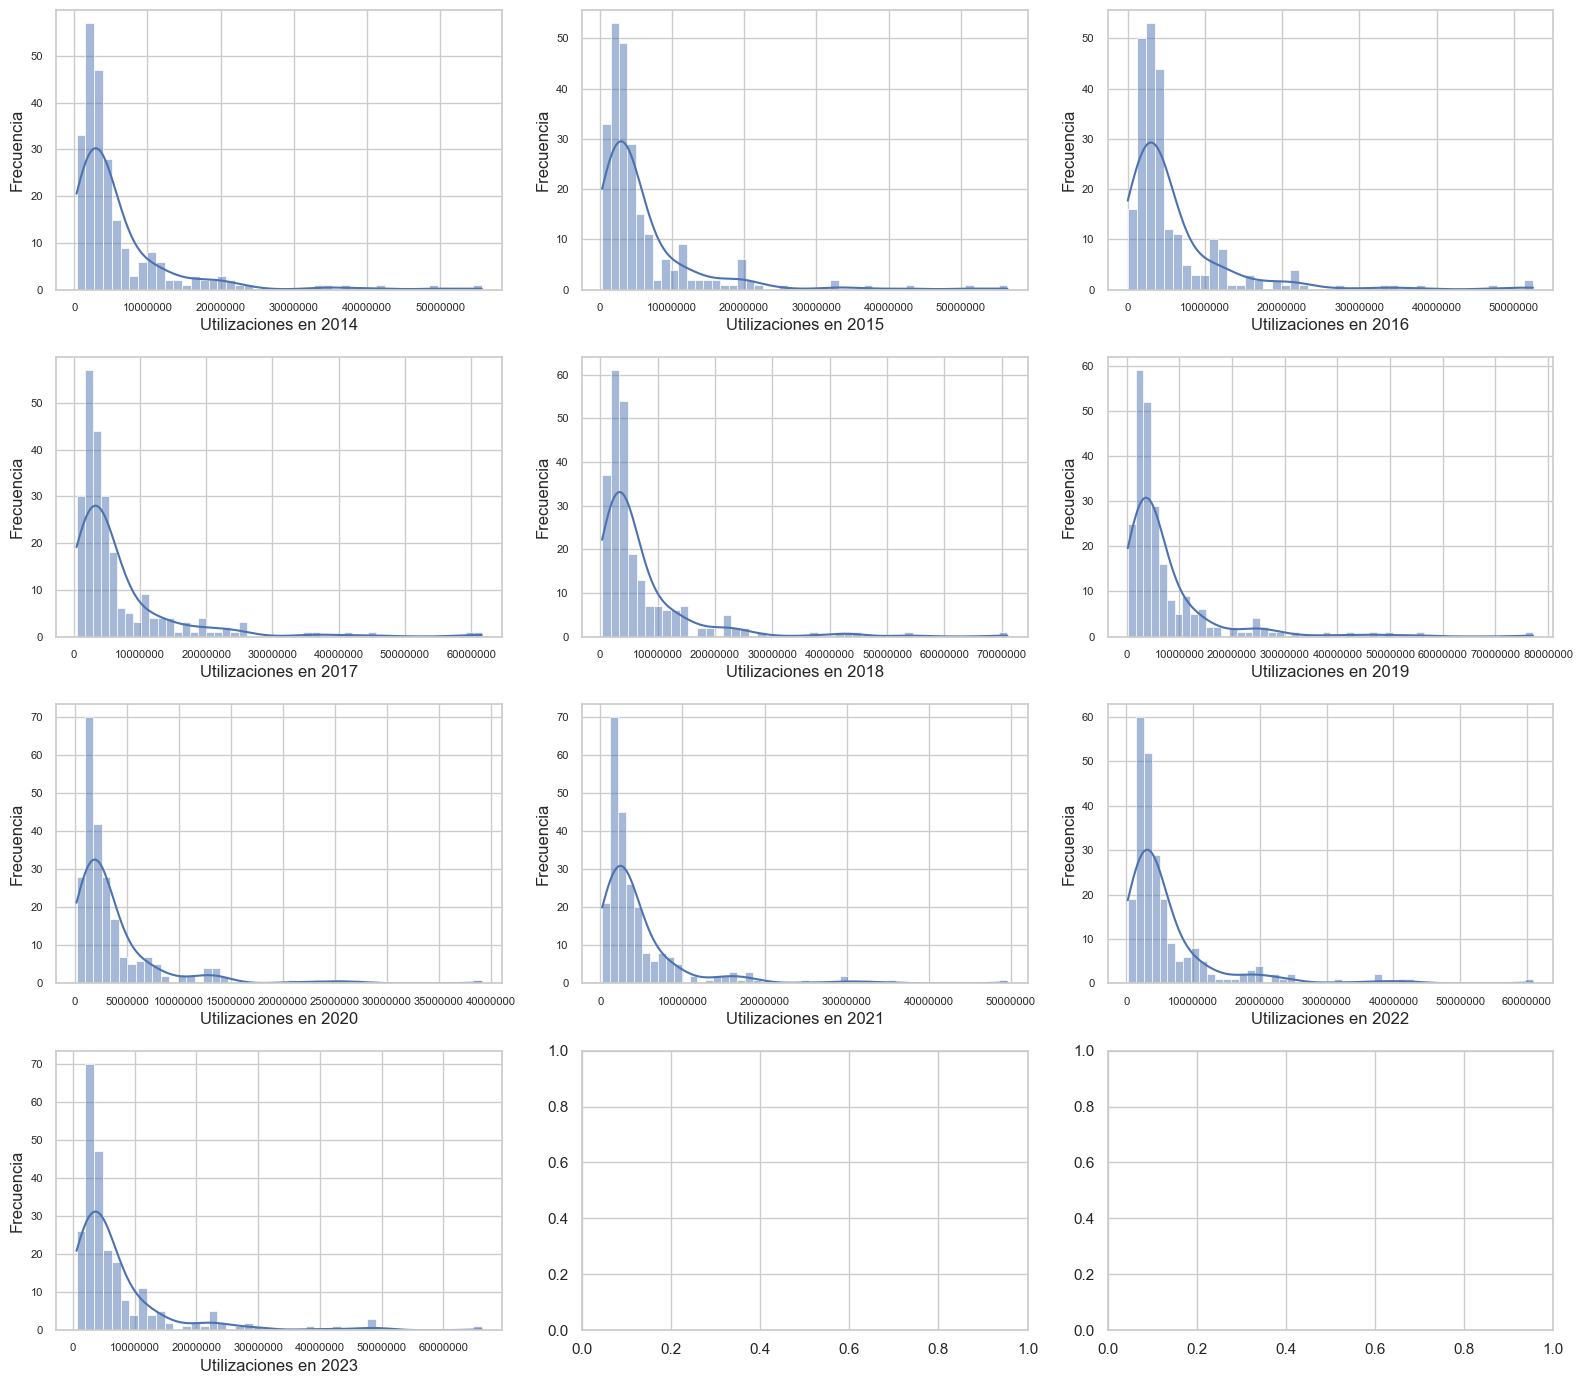

In [19]:
np.random.seed(42)
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 14))
axes = axes.flatten()
for i in range(10):
    sns.histplot(data=datos['Utilizaciones' + str(2014 + i)], kde=True, ax=axes[i])
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel(f'Utilizaciones en {2014 + i}')
    axes[i].ticklabel_format(style='plain', useOffset=False)
    axes[i].tick_params(axis='both', which='major', labelsize=8)
plt.tight_layout()
plt.show()

Todas las gráficas muestran una distribución asimétrica hacia la derecha y leptocúrtica/apuntada. Esto se traduce en que lo más común es que las estaciones sean utilizadas, independientemente del año, de 0 a 10.000.000 de veces (ya se ha visto antes, en la media por año, que la media por año oscila de 4.000.000 a 7.000.000 aproximadamente), pero llegando a ser probable en algunos casos que alguna estación sea utilizada 50.000.000, 60.000.000 o 70.000.000 de veces. ¿Cuáles son esas estaciones tan utilizadas y cuántas veces se utilizan? ¿Cuál es la media, moda y mediana? ¿Cuál es la curtosis y asimetría?

In [11]:
#Cálculo de la curtosis (kurt) y asimetría (skew) de las anteriores gráficas:
asim2014=datos['Utilizaciones2014'].skew()
asim2015=datos['Utilizaciones2015'].skew()
asim2016=datos['Utilizaciones2016'].skew()
asim2017=datos['Utilizaciones2017'].skew()
asim2018=datos['Utilizaciones2018'].skew()
asim2019=datos['Utilizaciones2019'].skew()
asim2020=datos['Utilizaciones2020'].skew()
asim2021=datos['Utilizaciones2021'].skew()
asim2022=datos['Utilizaciones2022'].skew()
asim2023=datos['Utilizaciones2023'].skew()
print('Asimetría de la curva de 2014: ',asim2014)
print('Asimetría de la curva de 2015: ',asim2015)
print('Asimetría de la curva de 2016: ',asim2016)
print('Asimetría de la curva de 2017: ',asim2017)
print('Asimetría de la curva de 2018: ',asim2018)
print('Asimetría de la curva de 2019: ',asim2019)
print('Asimetría de la curva de 2020: ',asim2020)
print('Asimetría de la curva de 2021: ',asim2021)
print('Asimetría de la curva de 2022: ',asim2022)
print('Asimetría de la curva de 2023: ',asim2023)
print('---------------------')
kurt2014=datos['Utilizaciones2014'].kurt()
kurt2015=datos['Utilizaciones2015'].kurt()
kurt2016=datos['Utilizaciones2016'].kurt()
kurt2017=datos['Utilizaciones2017'].kurt()
kurt2018=datos['Utilizaciones2018'].kurt()
kurt2019=datos['Utilizaciones2019'].kurt()
kurt2020=datos['Utilizaciones2020'].kurt()
kurt2021=datos['Utilizaciones2021'].kurt()
kurt2022=datos['Utilizaciones2022'].kurt()
kurt2023=datos['Utilizaciones2023'].kurt()
print('Curtosis de la curva de 2014: ',kurt2014)
print('Curtosis de la curva de 2015: ',kurt2015)
print('Curtosis de la curva de 2016: ',kurt2016)
print('Curtosis de la curva de 2017: ',kurt2017)
print('Curtosis de la curva de 2018: ',kurt2018)
print('Curtosis de la curva de 2019: ',kurt2019)
print('Curtosis de la curva de 2020: ',kurt2020)
print('Curtosis de la curva de 2021: ',kurt2021)
print('Curtosis de la curva de 2022: ',kurt2022)
print('Curtosis de la curva de 2023: ',kurt2023)
#Cálculo de la media, moda y mediana:
print('---------------------')
print('Media de 2014: ',int(media2014))
print('Media de 2015: ',int(media2015))
print('Media de 2016: ',int(media2016))
print('Media de 2017: ',int(media2017))
print('Media de 2018: ',int(media2018))
print('Media de 2019: ',int(media2019))
print('Media de 2020: ',int(media2020))
print('Media de 2021: ',int(media2021))
print('Media de 2022: ',int(media2022))
print('Media de 2023: ',int(media2023))
print('---------------------')
moda2014=mode(datos['Utilizaciones2014'])
moda2015=mode(datos['Utilizaciones2015'])
moda2016=mode(datos['Utilizaciones2016'])
moda2017=mode(datos['Utilizaciones2017'])
moda2018=mode(datos['Utilizaciones2018'])
moda2019=mode(datos['Utilizaciones2019'])
moda2020=mode(datos['Utilizaciones2020'])
moda2021=mode(datos['Utilizaciones2021'])
moda2022=mode(datos['Utilizaciones2022'])
moda2023=mode(datos['Utilizaciones2023'])
print('Moda de 2014: ',moda2014)
print('Moda de 2015: ',moda2015)
print('Moda de 2016: ',moda2016)
print('Moda de 2017: ',moda2017)
print('Moda de 2018: ',moda2018)
print('Moda de 2019: ',moda2019)
print('Moda de 2020: ',moda2020)
print('Moda de 2021: ',moda2021)
print('Moda de 2022: ',moda2022)
print('Moda de 2023: ',moda2023)
print('---------------------')
mediana2014=median(datos['Utilizaciones2014'])
mediana2015=median(datos['Utilizaciones2015'])
mediana2016=median(datos['Utilizaciones2016'])
mediana2017=median(datos['Utilizaciones2017'])
mediana2018=median(datos['Utilizaciones2018'])
mediana2019=median(datos['Utilizaciones2019'])
mediana2020=median(datos['Utilizaciones2020'])
mediana2021=median(datos['Utilizaciones2021'])
mediana2022=median(datos['Utilizaciones2022'])
mediana2023=median(datos['Utilizaciones2023'])
print('Mediana de 2014: ',mediana2014)
print('Mediana de 2015: ',mediana2015)
print('Mediana de 2016: ',mediana2016)
print('Mediana de 2017: ',mediana2017)
print('Mediana de 2018: ',mediana2018)
print('Mediana de 2019: ',mediana2019)
print('Mediana de 2020: ',mediana2020)
print('Mediana de 2021: ',mediana2021)
print('Mediana de 2022: ',mediana2022)
print('Mediana de 2023: ',mediana2023)
#¿Estación más utilizada y menos en cada año?
print('---------------------')
min2014=datos['Utilizaciones2014'].min()
min2015=datos['Utilizaciones2015'].min()
min2016=datos['Utilizaciones2016'].min()
min2017=datos['Utilizaciones2017'].min()
min2018=datos['Utilizaciones2018'].min()
min2019=datos['Utilizaciones2019'].min()
min2020=datos['Utilizaciones2020'].min()
min2021=datos['Utilizaciones2021'].min()
min2022=datos['Utilizaciones2022'].min()
min2023=datos['Utilizaciones2023'].min()
print('Mínimo de 2014: ',min2014)
print('Mínimo de 2015: ',min2015)
print('Mínimo de 2016: ',min2016)
print('Mínimo de 2017: ',min2017)
print('Mínimo de 2018: ',min2018)
print('Mínimo de 2019: ',min2019)
print('Mínimo de 2020: ',min2020)
print('Mínimo de 2021: ',min2021)
print('Mínimo de 2022: ',min2022)
print('Mínimo de 2023: ',min2023)
print('---------------------')
min2014_index = datos['Utilizaciones2014'].idxmin()
min2015_index = datos['Utilizaciones2015'].idxmin()
min2016_index = datos['Utilizaciones2016'].idxmin()
min2017_index = datos['Utilizaciones2017'].idxmin()
min2018_index = datos['Utilizaciones2018'].idxmin()
min2019_index = datos['Utilizaciones2019'].idxmin()
min2020_index = datos['Utilizaciones2020'].idxmin()
min2021_index = datos['Utilizaciones2021'].idxmin()
min2022_index = datos['Utilizaciones2022'].idxmin()
min2023_index = datos['Utilizaciones2023'].idxmin()

min2014_station = datos.loc[min2014_index, 'NombreEstacion']
min2015_station = datos.loc[min2015_index, 'NombreEstacion']
min2016_station = datos.loc[min2016_index, 'NombreEstacion']
min2017_station = datos.loc[min2017_index, 'NombreEstacion']
min2018_station = datos.loc[min2018_index, 'NombreEstacion']
min2019_station = datos.loc[min2019_index, 'NombreEstacion']
min2020_station = datos.loc[min2020_index, 'NombreEstacion']
min2021_station = datos.loc[min2021_index, 'NombreEstacion']
min2022_station = datos.loc[min2022_index, 'NombreEstacion']
min2023_station = datos.loc[min2023_index, 'NombreEstacion']

print('Mínimo de 2014: ', min2014_station)
print('Mínimo de 2015: ', min2015_station)
print('Mínimo de 2016: ', min2016_station)
print('Mínimo de 2017: ', min2017_station)
print('Mínimo de 2018: ', min2018_station)
print('Mínimo de 2019: ', min2019_station)
print('Mínimo de 2020: ', min2020_station)
print('Mínimo de 2021: ', min2021_station)
print('Mínimo de 2022: ', min2022_station)
print('Mínimo de 2023: ', min2023_station)
print('---------------------')
max2014=datos['Utilizaciones2014'].max()
max2015=datos['Utilizaciones2015'].max()
max2016=datos['Utilizaciones2016'].max()
max2017=datos['Utilizaciones2017'].max()
max2018=datos['Utilizaciones2018'].max()
max2019=datos['Utilizaciones2019'].max()
max2020=datos['Utilizaciones2020'].max()
max2021=datos['Utilizaciones2021'].max()
max2022=datos['Utilizaciones2022'].max()
max2023=datos['Utilizaciones2023'].max()
print('Máximo de 2014: ',max2014)
print('Máximo de 2015: ',max2015)
print('Máximo de 2016: ',max2016)
print('Máximo de 2017: ',max2017)
print('Máximo de 2018: ',max2018)
print('Máximo de 2019: ',max2019)
print('Máximo de 2020: ',max2020)
print('Máximo de 2021: ',max2021)
print('Máximo de 2022: ',max2022)
print('Máximo de 2023: ',max2023)
max2014_index = datos['Utilizaciones2014'].idxmax()
max2015_index = datos['Utilizaciones2015'].idxmax()
max2016_index = datos['Utilizaciones2016'].idxmax()
max2017_index = datos['Utilizaciones2017'].idxmax()
max2018_index = datos['Utilizaciones2018'].idxmax()
max2019_index = datos['Utilizaciones2019'].idxmax()
max2020_index = datos['Utilizaciones2020'].idxmax()
max2021_index = datos['Utilizaciones2021'].idxmax()
max2022_index = datos['Utilizaciones2022'].idxmax()
max2023_index = datos['Utilizaciones2023'].idxmax()
print('---------------------')
max2014_station = datos.loc[max2014_index, 'NombreEstacion']
max2015_station = datos.loc[max2015_index, 'NombreEstacion']
max2016_station = datos.loc[max2016_index, 'NombreEstacion']
max2017_station = datos.loc[max2017_index, 'NombreEstacion']
max2018_station = datos.loc[max2018_index, 'NombreEstacion']
max2019_station = datos.loc[max2019_index, 'NombreEstacion']
max2020_station = datos.loc[max2020_index, 'NombreEstacion']
max2021_station = datos.loc[max2021_index, 'NombreEstacion']
max2022_station = datos.loc[max2022_index, 'NombreEstacion']
max2023_station = datos.loc[max2023_index, 'NombreEstacion']

print('Máximo de 2014: ', max2014_station)
print('Máximo de 2015: ', max2015_station)
print('Máximo de 2016: ', max2016_station)
print('Máximo de 2017: ', max2017_station)
print('Máximo de 2018: ', max2018_station)
print('Máximo de 2019: ', max2019_station)
print('Máximo de 2020: ', max2020_station)
print('Máximo de 2021: ', max2021_station)
print('Máximo de 2022: ', max2022_station)
print('Máximo de 2023: ', max2023_station)

Asimetría de la curva de 2014:  3.5086727000776277
Asimetría de la curva de 2015:  3.5600831902464796
Asimetría de la curva de 2016:  3.5082577650147693
Asimetría de la curva de 2017:  3.6097418927001463
Asimetría de la curva de 2018:  3.7667775179482335
Asimetría de la curva de 2019:  3.793330613098261
Asimetría de la curva de 2020:  3.710680575336537
Asimetría de la curva de 2021:  3.76781665297419
Asimetría de la curva de 2022:  3.585392525599508
Asimetría de la curva de 2023:  3.4651580700230435
---------------------
Curtosis de la curva de 2014:  15.443181196442028
Curtosis de la curva de 2015:  16.05552030550555
Curtosis de la curva de 2016:  15.042467055217339
Curtosis de la curva de 2017:  16.5824193055611
Curtosis de la curva de 2018:  18.500341574537337
Curtosis de la curva de 2019:  18.657735453725042
Curtosis de la curva de 2020:  17.797587122225067
Curtosis de la curva de 2021:  18.31616660553588
Curtosis de la curva de 2022:  16.47096245503839
Curtosis de la curva de 2023

Todos los valores de la asimetría son superiores a 0, por lo que las distribuciones, efectivamente, son asimétricas a la derecha. Todos los valores de la curtosis son superiores a 3, por lo que todas las distribuciones, efectivamente, son leptocúrticas o apuntadas. 

La moda de 2014 es de 11.000.0000 (0, ya que es el valor por el que hemos sustituido los ceros para que no hubiesen problemas al calcular las estaciones con mínimo tránsito) ya que las estaciones de Arroyofresno y Paco de Lucía no existían, por lo que tienen un valor de 0 en el dataset. 

Los valores de las medias  están anteriormente en el Notebook mencionados.

Parece que Sol es la estación más utilizada del Metro de Madrid y la menos utilizada Hospital del Henares. El año que una estación de Metro de Madrid registró más utilizaciones fue en 2019 con 77.135.814 (estación de Sol), seguido de 2018 (también Sol) con 70.953.620 utilizaciones.

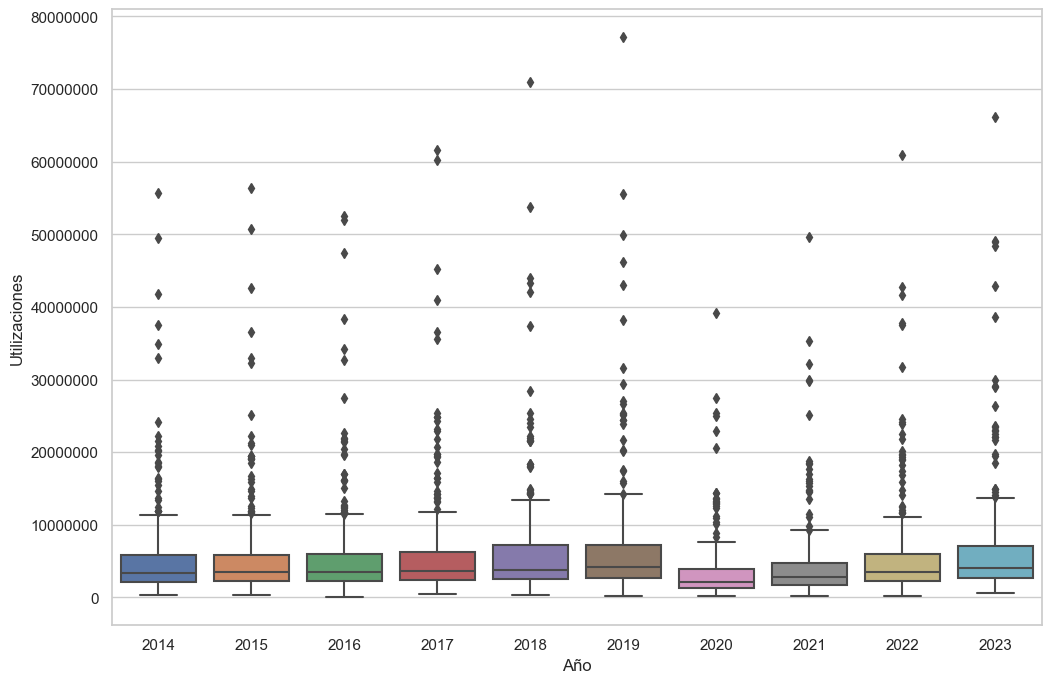

In [12]:
#Gráfico de caja y bigotes:
selected_data = [datos['Utilizaciones2014'],datos['Utilizaciones2015'],datos['Utilizaciones2016'],datos['Utilizaciones2017'],
                datos['Utilizaciones2018'],datos['Utilizaciones2019'],datos['Utilizaciones2020'],datos['Utilizaciones2021'],datos['Utilizaciones2022']
                ,datos['Utilizaciones2023']]
nombres = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022','2023']
plt.figure(figsize=(12, 8))
sns.boxplot(data=selected_data)
plt.xticks(range(len(nombres)), nombres)
plt.xlabel('Año')
plt.ylabel('Utilizaciones')
plt.ticklabel_format(style='plain', axis='y')

Se observa que valores superiores a aproximadamente 11.000.000 de utilizaciones son valores atípicos para todos los años (calculado abajo), excepto para 2020 y 2021 que incluso tiene valores atípicos menores por el Covid. Como no pueden haber utilizaciones negativas, el extremo inferior de todos los gráficos se sitúa en el 0 y no hay valores atípicos inferiores. ¿Cuáles son los valores exactos para cada año del extremo superior, el cuartil superior (Q3) y el cuartil inferior (Q1)?

In [13]:
#Cálculo de los valores del extremo superior (maximo sin valores atípicos), cuartil superior e inferior:
q12014=np.percentile(datos['Utilizaciones2014'],25)
q12015=np.percentile(datos['Utilizaciones2015'],25)
q12016=np.percentile(datos['Utilizaciones2016'],25)
q12017=np.percentile(datos['Utilizaciones2017'],25)
q12018=np.percentile(datos['Utilizaciones2018'],25)
q12019=np.percentile(datos['Utilizaciones2019'],25)
q12020=np.percentile(datos['Utilizaciones2020'],25)
q12021=np.percentile(datos['Utilizaciones2021'],25)
q12022=np.percentile(datos['Utilizaciones2022'],25)
q12023=np.percentile(datos['Utilizaciones2023'],25)
q32014=np.percentile(datos['Utilizaciones2014'],75)
q32015=np.percentile(datos['Utilizaciones2015'],75)
q32016=np.percentile(datos['Utilizaciones2016'],75)
q32017=np.percentile(datos['Utilizaciones2017'],75)
q32018=np.percentile(datos['Utilizaciones2018'],75)
q32019=np.percentile(datos['Utilizaciones2019'],75)
q32020=np.percentile(datos['Utilizaciones2020'],75)
q32021=np.percentile(datos['Utilizaciones2021'],75)
q32022=np.percentile(datos['Utilizaciones2022'],75)
q32023=np.percentile(datos['Utilizaciones2023'],75)

print('Primer cuartil de los datos de 2014: ',int(q12014),'/ Tercer cuartil de los datos de 2014: ',int(q32014))
print('Primer cuartil de los datos de 2015: ',int(q12015),'/ Tercer cuartil de los datos de 2015: ',int(q32015))
print('Primer cuartil de los datos de 2016: ',int(q12016),'/ Tercer cuartil de los datos de 2016: ',int(q32016))
print('Primer cuartil de los datos de 2017: ',int(q12017),'/ Tercer cuartil de los datos de 2017: ',int(q32017))
print('Primer cuartil de los datos de 2018: ',int(q12018),'/ Tercer cuartil de los datos de 2018: ',int(q32018))
print('Primer cuartil de los datos de 2019: ',int(q12019),'/ Tercer cuartil de los datos de 2019: ',int(q32019))
print('Primer cuartil de los datos de 2020: ',int(q12020),'/ Tercer cuartil de los datos de 2020: ',int(q32020))
print('Primer cuartil de los datos de 2021: ',int(q12021),'/ Tercer cuartil de los datos de 2021: ',int(q32021))
print('Primer cuartil de los datos de 2022: ',int(q12022),'/ Tercer cuartil de los datos de 2022: ',int(q32022))
print('Primer cuartil de los datos de 2023: ',int(q12023),'/ Tercer cuartil de los datos de 2023: ',int(q32023))
#Cálculo del extremo superior:
iqr2014 = q32014 - q12014
iqr2015 = q32015 - q12015
iqr2016 = q32016 - q12016
iqr2017 = q32017 - q12017
iqr2018 = q32018 - q12018
iqr2019 = q32019 - q12019
iqr2020 = q32020 - q12020
iqr2021 = q32021 - q12021
iqr2022 = q32022 - q12022
iqr2023 = q32023 - q12023
longBigote2014 = 1.5 * iqr2014
longBigote2015 = 1.5 * iqr2015
longBigote2016 = 1.5 * iqr2016
longBigote2017 = 1.5 * iqr2017
longBigote2018 = 1.5 * iqr2018
longBigote2019 = 1.5 * iqr2019
longBigote2020 = 1.5 * iqr2020
longBigote2021 = 1.5 * iqr2021
longBigote2022 = 1.5 * iqr2022
longBigote2023 = 1.5 * iqr2023
extremoSup2014 = q32014 + longBigote2014
extremoSup2015 = q32015 + longBigote2015
extremoSup2016 = q32016 + longBigote2016
extremoSup2017 = q32017 + longBigote2017
extremoSup2018 = q32018 + longBigote2018
extremoSup2019 = q32019 + longBigote2019
extremoSup2020 = q32020 + longBigote2020
extremoSup2021 = q32021 + longBigote2021
extremoSup2022 = q32022 + longBigote2022
extremoSup2023 = q32023 + longBigote2023
print('----------------------------')
print('Los valores superiores al extremo superior del bigote ya son valores atípicos.')
print('----------------------------')
print('Extremo superior del bigote de 2014: ',int(extremoSup2014))
print('Extremo superior del bigote de 2015: ',int(extremoSup2015))
print('Extremo superior del bigote de 2016: ',int(extremoSup2016))
print('Extremo superior del bigote de 2017: ',int(extremoSup2017))
print('Extremo superior del bigote de 2018: ',int(extremoSup2018))
print('Extremo superior del bigote de 2019: ',int(extremoSup2019))
print('Extremo superior del bigote de 2020: ',int(extremoSup2020))
print('Extremo superior del bigote de 2021: ',int(extremoSup2021))
print('Extremo superior del bigote de 2022: ',int(extremoSup2022))
print('Extremo superior del bigote de 2023: ',int(extremoSup2023))

Primer cuartil de los datos de 2014:  2118290 / Tercer cuartil de los datos de 2014:  5845624
Primer cuartil de los datos de 2015:  2217782 / Tercer cuartil de los datos de 2015:  5879855
Primer cuartil de los datos de 2016:  2267292 / Tercer cuartil de los datos de 2016:  5953996
Primer cuartil de los datos de 2017:  2459123 / Tercer cuartil de los datos de 2017:  6321562
Primer cuartil de los datos de 2018:  2488684 / Tercer cuartil de los datos de 2018:  7158034
Primer cuartil de los datos de 2019:  2624806 / Tercer cuartil de los datos de 2019:  7284930
Primer cuartil de los datos de 2020:  1343771 / Tercer cuartil de los datos de 2020:  3877174
Primer cuartil de los datos de 2021:  1775639 / Tercer cuartil de los datos de 2021:  4784869
Primer cuartil de los datos de 2022:  2317488 / Tercer cuartil de los datos de 2022:  6003329
Primer cuartil de los datos de 2023:  2703299 / Tercer cuartil de los datos de 2023:  7124266
----------------------------
Los valores superiores al extre

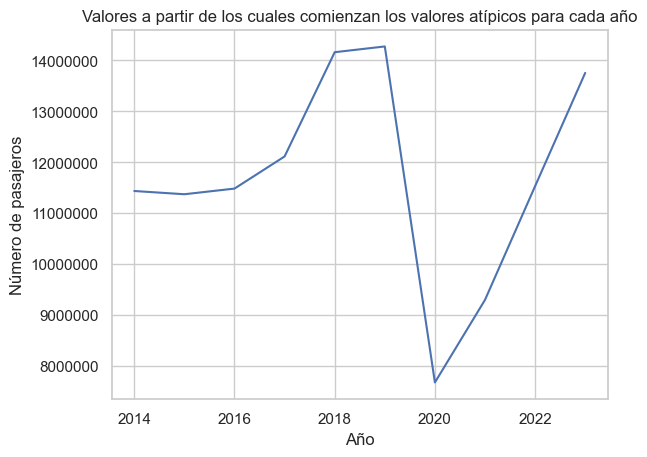

In [14]:
extremos = [extremoSup2014,extremoSup2015,extremoSup2016,extremoSup2017,extremoSup2018,extremoSup2019,extremoSup2020
          ,extremoSup2021,extremoSup2022,extremoSup2023]
anios = [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]
plt.plot(anios,extremos)
plt.title('Valores a partir de los cuales comienzan los valores atípicos para cada año')
plt.ylabel('Número de pasajeros')
plt.xlabel('Año')
plt.ticklabel_format(useOffset=False, style='plain')

Diagrama de dispersión para cada año:

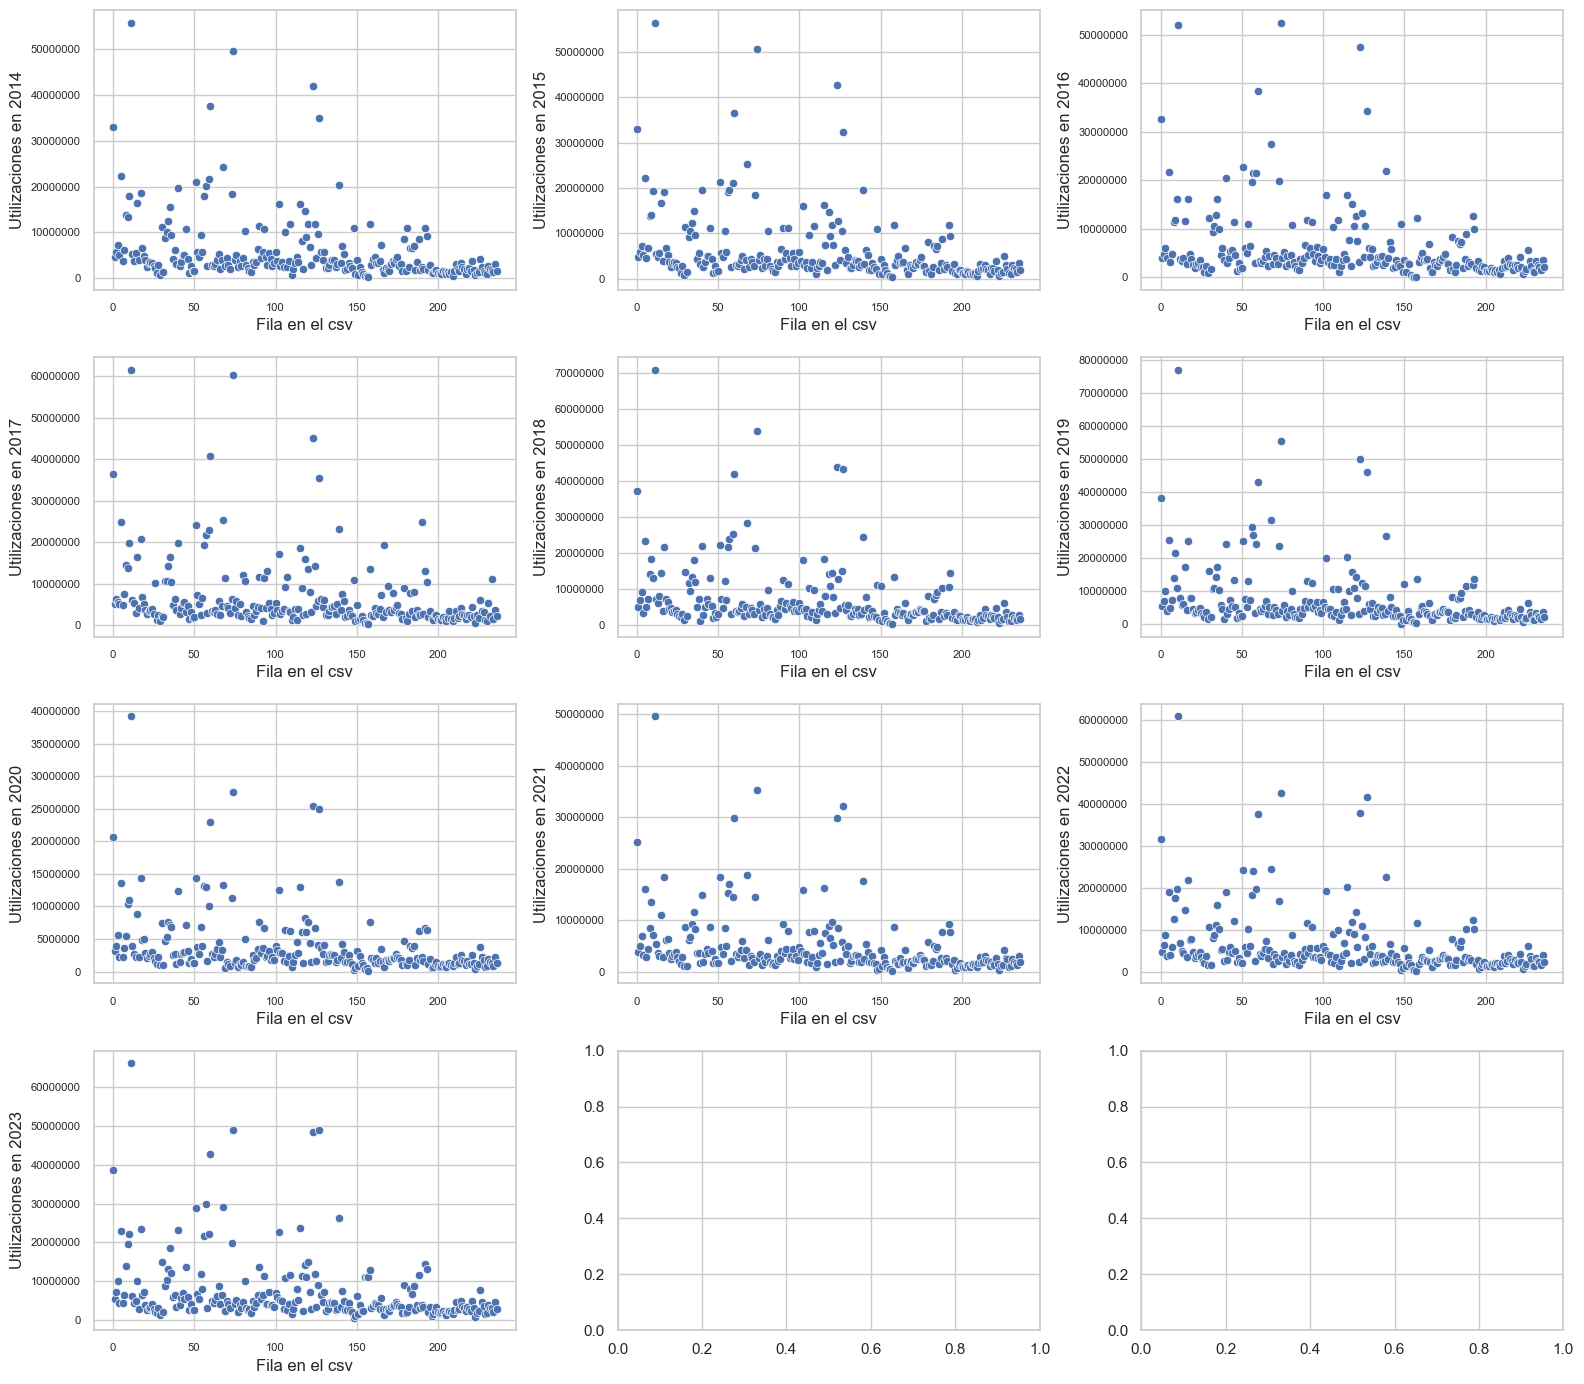

In [20]:
np.random.seed(42)
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 14))
axes = axes.flatten()
for i in range(10):
    sns.scatterplot(data=datos['Utilizaciones' + str(2014 + i)], ax=axes[i])
    axes[i].set_xlabel('Fila en el csv')
    axes[i].set_ylabel(f'Utilizaciones en {2014 + i}')
    axes[i].ticklabel_format(style='plain', useOffset=False)
    axes[i].tick_params(axis='both', which='major', labelsize=8)
plt.tight_layout()
plt.show()

Se observa que la mayoría de los datos se encuentran entre 0 y 10.000.000, a excepción de las estaciones más utilizadas que son valores atípicos (los mismos valores que en el gráfico de caja y bigotes) y los que se encuentran más dispersos.

In [16]:
import ipywidgets as widgets
from IPython.display import display

def update_plot(year, top_n):
    plt.clf()
    plt.figure(figsize=(20, 8))
    
    sorted_estaciones = datos.sort_values(by=f'Utilizaciones{year}', ascending=False).head(top_n)
    
    plt.bar(sorted_estaciones['NombreEstacion'], sorted_estaciones[f'Utilizaciones{year}'], color='skyblue')
    plt.xticks(rotation=90)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xlabel('Estaciones')
    plt.ylabel(f'Utilizaciones {year}')
    plt.title(f'Utilizaciones de Metro Madrid por Estación en {year}')
    plt.tight_layout()
    plt.show()

top_n_selector = widgets.IntSlider(
    value=10,
    min=1,
    max=len(datos),
    step=1,
    description='Top N estaciones:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

year_selector = widgets.Dropdown(
    options=[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    value=2014,
    description='Año:',
    disabled=False,
)

interactive_plot = widgets.interactive(update_plot, year=year_selector, top_n=top_n_selector)
display(interactive_plot)

interactive(children=(Dropdown(description='Año:', options=(2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 20…

Con esta paleta de colores divergente (valores bajos: rojo, valores medios: amarillo, valores altos:azul) se diferencian perfectamente las estaciones más utilizadas de las que tienen una concurrencia normal. 

Entre las más visitadas se encuentran: Plaza de Castilla (valores medios), Cuatro Caminos (valores medios), Sol (valores altos), Pacífico (valores medios), Ópera (valores medios), Atocha-Renfe (valores medios), Legazpi (valores medios), Callao (valores medios), Plaza de España (valores medios), Moncloa (valores altos), Arguelles (valores medios), Alonso Martínez (valores medios), Diego de León (valores medios), Avenida de América (valores altos), Plaza Elíptica (valores medios), Nuevos Ministerios (valores altos), Príncipe Pío (valores altos) y Gregorio Marañón (valores medios).

Se puede observar perfectamente en qué año es más utilizada cada estación.

Las estaciones de Madrid centro (zona más turística de Madrid) e intercambiadores son las más utilizadas.

Q-Q Plot

KeyError: 'Utilizaciones2024'

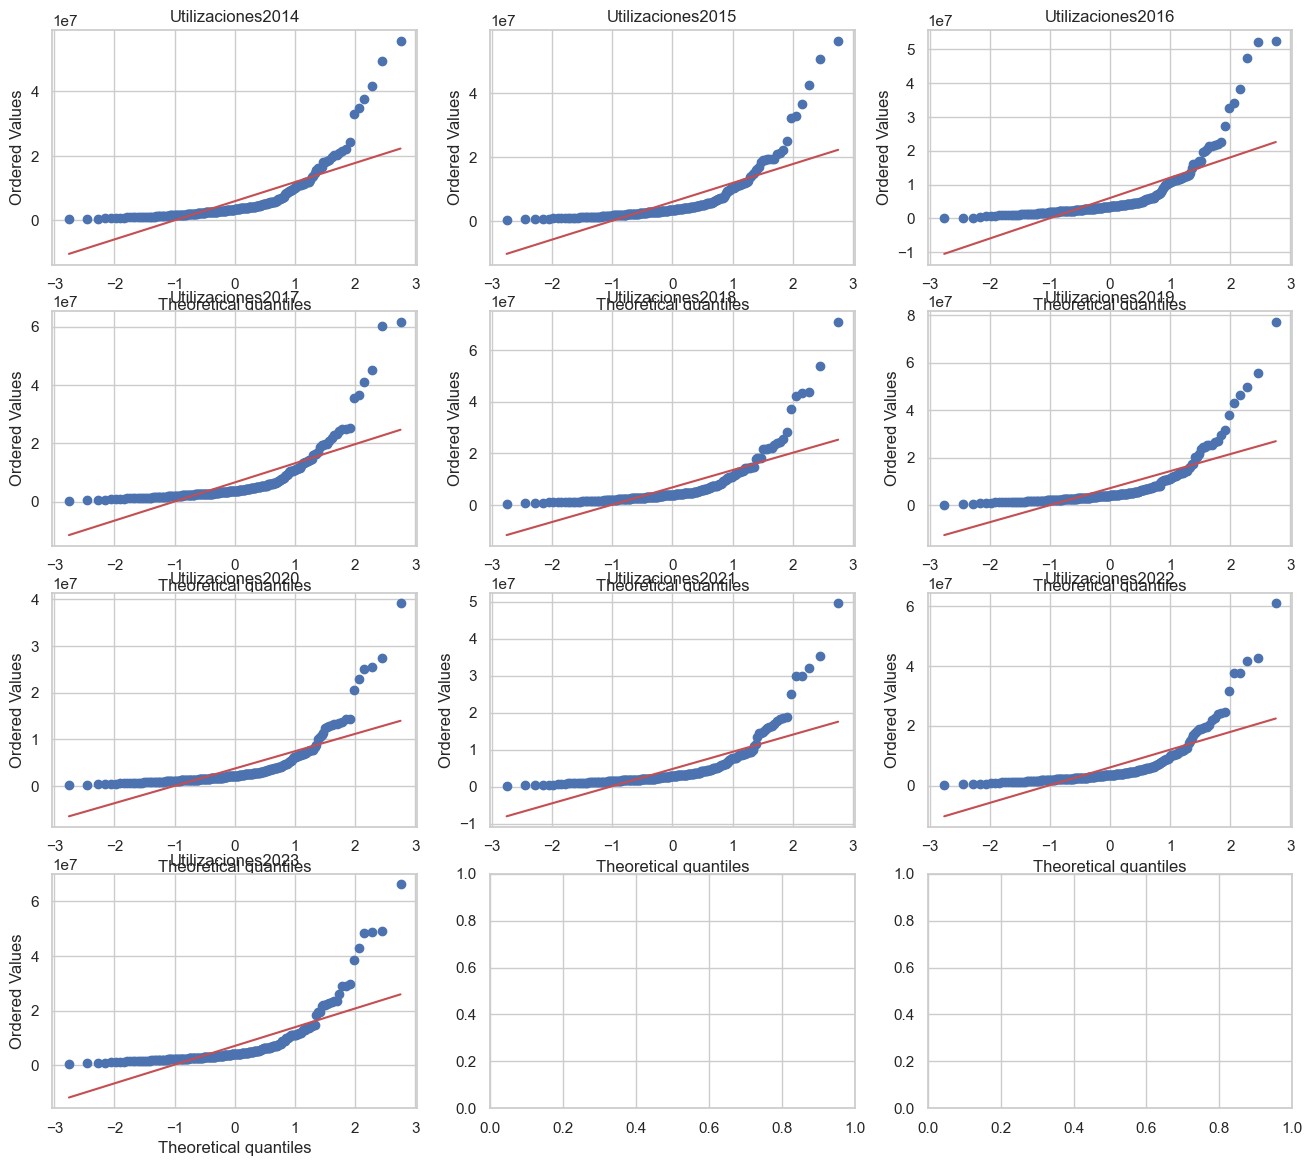

In [21]:
import scipy
from scipy.stats import norm
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 14))
axes = axes.flatten()
for i, ax in enumerate(axes):
    scipy.stats.probplot(datos['Utilizaciones'+ str(2014+i)], dist='norm', fit=True, plot=ax)
    ax.set_title('Utilizaciones'+ str(2014+i))
plt.tight_layout()
plt.show()

Se puede comprobar como ninguna de las distribuciones (anteriormente se ha demostrado), es una distribución normal.